In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_raw  = pd.read_csv("heart.csv")
data = data_raw.copy()

In [3]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


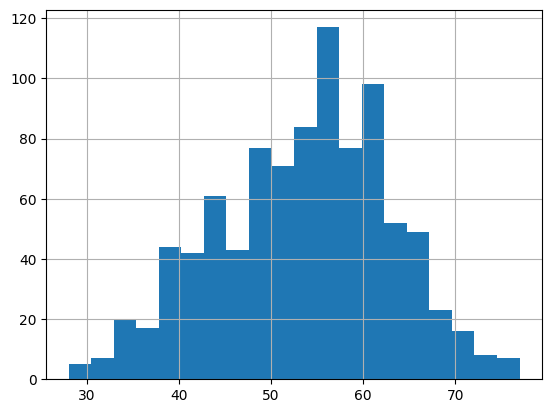

In [4]:
data.Age.hist(bins= 20)
plt.show()

Manual scailing by dividing all dataset to maximum data of dataset.

In [5]:
max_age = data.Age / data.Age.max()

In [6]:
max_age.std()

0.12250151307444171

<Axes: >

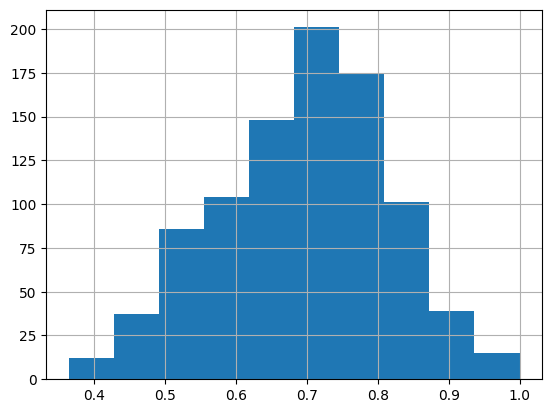

In [7]:
max_age.hist()

Scaling with minmaxscaler that was an scaler explained in readme.

In [8]:
from sklearn.preprocessing import MinMaxScaler

In [9]:
scaler = MinMaxScaler()
mm_age = scaler.fit_transform(data[["Age"]])

(array([ 12.,  37.,  86., 104., 148., 201., 175., 101.,  39.,  15.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

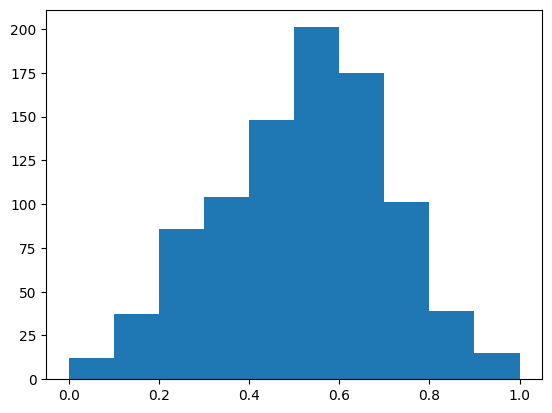

In [10]:
plt.hist(mm_age)

In [11]:
mm_age.min()

0.0

In [12]:
mm_age.max()

1.0

In [13]:
mm_age.std()

0.19239750032966313

Scaling with standardscaler that was an scaler explained in readme.

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
s_scaler = StandardScaler()
standard_age = s_scaler.fit_transform(data[["Age"]])

In [16]:
standard_age.min()

-2.7060147534137067

In [17]:
standard_age.max()

2.491557971213961

In [18]:
standard_age.std()

1.0

In [19]:
data.Age = s_scaler.fit_transform(data[["Age"]])

In [20]:
data.Age.describe()

count    9.180000e+02
mean    -1.083616e-16
std      1.000545e+00
min     -2.706015e+00
25%     -6.906294e-01
50%      5.188098e-02
75%      6.883185e-01
max      2.491558e+00
Name: Age, dtype: float64

In [21]:
from sklearn.preprocessing import Binarizer

For converting age<0 to zero.

In [22]:
binar = Binarizer(threshold = 0)
bin_age = binar.fit_transform(data[['Age']])

In [23]:
bin_age

array([[0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [1.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],
       [0.],
       [1.],
       [0.],
       [0.],

In [24]:
np.unique(bin_age)

array([0., 1.])

Setting our dataset in [0,1] with normalizer.

In [25]:
from sklearn.preprocessing import Normalizer

In [26]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,-1.433140,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,-0.478484,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,-1.751359,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,-0.584556,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,0.051881,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


Before normalizing we have to change the string data to the numeric format.

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [28]:
data['Sex'] = le.fit_transform(data['Sex'])
data['ChestPainType'] = le.fit_transform(data['ChestPainType'])
data['RestingECG'] = le.fit_transform(data['RestingECG'])
data['ExerciseAngina'] = le.fit_transform(data['ExerciseAngina'])
data['ST_Slope'] = le.fit_transform(data['ST_Slope'])

In [29]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,-1.433140,1,1,140,289,0,1,172,0,0.0,2,0
1,-0.478484,0,2,160,180,0,1,156,0,1.0,1,1
2,-1.751359,1,1,130,283,0,2,98,0,0.0,2,0
3,-0.584556,0,0,138,214,0,1,108,1,1.5,1,1
4,0.051881,1,2,150,195,0,1,122,0,0.0,2,0


In [30]:
column_names = data.columns
norm = Normalizer()
data = norm.fit_transform(data)
data = pd.DataFrame(data , columns=column_names)

In [31]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,-0.003934,0.002745,0.002745,0.384299,0.793304,0.0,0.002745,0.472139,0.000000,0.000000,0.005490,0.000000
1,-0.001667,0.000000,0.006970,0.557575,0.627272,0.0,0.003485,0.543636,0.000000,0.003485,0.003485,0.003485
2,-0.005364,0.003063,0.003063,0.398155,0.866753,0.0,0.006125,0.300148,0.000000,0.000000,0.006125,0.000000
3,-0.002113,0.000000,0.000000,0.498906,0.773665,0.0,0.003615,0.390448,0.003615,0.005423,0.003615,0.003615
4,0.000189,0.003641,0.007283,0.546199,0.710059,0.0,0.003641,0.444242,0.000000,0.000000,0.007283,0.000000
